# Final Project

## Data Processing

### Import Packages

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torchani
import matplotlib.pyplot as plt

### Use GPU

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Set up AEV computer

#### AEV: Atomic Environment Vector (atomic features)

Ref: Chem. Sci., 2017, 8, 3192

In [3]:
def init_aev_computer():
    Rcr = 5.2
    Rca = 3.5
    EtaR = torch.tensor([16], dtype=torch.float, device=device)
    ShfR = torch.tensor([
        0.900000, 1.168750, 1.437500, 1.706250, 
        1.975000, 2.243750, 2.512500, 2.781250, 
        3.050000, 3.318750, 3.587500, 3.856250, 
        4.125000, 4.393750, 4.662500, 4.931250
    ], dtype=torch.float, device=device)


    EtaA = torch.tensor([8], dtype=torch.float, device=device)
    Zeta = torch.tensor([32], dtype=torch.float, device=device)
    ShfA = torch.tensor([0.90, 1.55, 2.20, 2.85], dtype=torch.float, device=device)
    ShfZ = torch.tensor([
        0.19634954, 0.58904862, 0.9817477, 1.37444680, 
        1.76714590, 2.15984490, 2.5525440, 2.94524300
    ], dtype=torch.float, device=device)

    num_species = 4
    aev_computer = torchani.AEVComputer(
        Rcr, Rca, EtaR, ShfR, EtaA, Zeta, ShfA, ShfZ, num_species
    )
    return aev_computer

aev_computer = init_aev_computer()
aev_dim = aev_computer.aev_length
print(aev_dim)

384


### Prepare dataset & split

In [4]:
def load_ani_dataset(dspath):
    self_energies = torch.tensor([
        0.500607632585, -37.8302333826,
        -54.5680045287, -75.0362229210
    ], dtype=torch.float, device=device)
    energy_shifter = torchani.utils.EnergyShifter(None)
    species_order = ['H', 'C', 'N', 'O']

    dataset = torchani.data.load(dspath)
    dataset = dataset.subtract_self_energies(energy_shifter, species_order)
    dataset = dataset.species_to_indices(species_order)
    dataset = dataset.shuffle()
    return dataset

dataset = load_ani_dataset("./ani_gdb_s01_to_s04.h5")
train_data, val_data, test_data = dataset.split(8/10,1/10,None)

### Batching

In [5]:
batch_size = 8192
train_data_loader = train_data.collate(batch_size).cache()
val_data_loader = val_data.collate(batch_size).cache()
test_data_loader = test_data.collate(batch_size).cache()

### Torchani API

In [6]:
class AtomicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H,net_C,net_N,net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

In [7]:
train_data_batch = next(iter(train_data_loader))

## Model

In [8]:
class ANITrainer:
    def __init__(self, model, batch_size, learning_rate, epoch, l2):
        self.model = model
        
        num_params = sum(item.numel() for item in model.parameters())
        print(f"{model.__class__.__name__} - Number of parameters: {num_params}")
        
        self.batch_size = batch_size
        self.optimizer = torch.optim.Adam(model.parameters(), learning_rate, weight_decay=l2)
        self.epoch = epoch
    
    def train(self, train_data, val_data, early_stop=True, draw_curve=True):
        self.model.train()
        
        # init data loader
        print("Initialize training data...")
        train_data_loader = train_data.collate(batch_size).cache()
        
        # definition of loss function: MSE
        loss_func = nn.MSELoss()
        
        # record epoch losses
        train_loss_list = []
        val_loss_list = []
        lowest_val_loss = np.inf
        train_epoch_loss = 0
        
        for i in tqdm(range(self.epoch), leave=True):
            train_epoch_loss = 0.0
            for train_data_batch in train_data_loader:
                
                # compute energies
                species = train_data_batch['species'].to(device)
                coords = train_data_batch['coordinates'].to(device)
                true_energies = train_data_batch['energies'].to(device).float()
                _, pred_energies = model((species, coords))
                
                # compute loss
                batch_loss = loss_func(pred_energies, true_energies)
                
                # do a step
                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()
                
                batch_importance = len(train_data_batch) / len(train_data_loader)
                train_epoch_loss += batch_loss.detach().item() * batch_importance
            
            # use the self.evaluate to get loss on the validation set 
            val_epoch_loss = self.evaluate(val_data).item()
            
            # append the losses
            train_loss_list.append(train_epoch_loss)
            val_loss_list.append(val_epoch_loss)
            
            if early_stop:
                if val_epoch_loss < lowest_val_loss:
                    lowest_val_loss = val_epoch_loss
                    weights = self.model.state_dict()
        
        if draw_curve:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.set_yscale("log")
            # Plot train loss and validation loss
            ax.plot(np.arange(self.epoch), train_loss_list, label='Validation')
            ax.plot(np.arange(self.epoch), val_loss_list, label='Train')
            ax.legend()
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Loss")
        
        if early_stop:
            self.model.load_state_dict(weights)
        
        return train_loss_list, val_loss_list
    
    
    def evaluate(self, data, draw_plot=False):
        
        # init data loader
        data_loader = data.collate(batch_size).cache()
        
        # init loss function
        loss_func = nn.MSELoss()
        total_loss = 0.0
        
        if draw_plot:
            true_energies_all = []
            pred_energies_all = []
            
        with torch.no_grad():
            for batch_data in data_loader:
                
                # compute energies
                species = batch_data['species'].to(device)
                coords = batch_data['coordinates'].to(device)
                true_energies = batch_data['energies'].to(device).float()
                _, pred_energies = model((species, coords))
                
                # compute loss
                batch_loss = loss_func(pred_energies, true_energies)
                
                batch_importance = len(batch_data) / len(data)
                total_loss += batch_loss * batch_importance
                
                if draw_plot:
                    true_energies_all.append(true_energies.detach().cpu().numpy().flatten())
                    pred_energies_all.append(pred_energies.detach().cpu().numpy().flatten())

        if draw_plot:
            true_energies_all = np.concatenate(true_energies_all)
            pred_energies_all = np.concatenate(pred_energies_all)
            # Report the mean absolute error
            # The unit of energies in the dataset is hartree
            # 1 hartree = 627.5094738898777 kcal/mol
            # RMSE = sqrt( mean( (true - pred)^2 ))
            hartree2kcalmol = 627.5094738898777
            rmse = np.sqrt(np.mean(((true_energies_all-pred_energies_all)*hartree2kcalmol)**2))
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.scatter(true_energies_all, pred_energies_all, label=f"RMSE: {rmse:.2f} kcal/mol", s=2)
            ax.set_xlabel("Ground Truth")
            ax.set_ylabel("Predicted")
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            vmin, vmax = min(xmin, ymin), max(xmax, ymax)
            ax.set_xlim(vmin, vmax)
            ax.set_ylim(vmin, vmax)
            ax.plot([vmin, vmax], [vmin, vmax], color='red')
            ax.legend()
            
        return total_loss

In [9]:
class AtomicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

ani_net = torchani.ANIModel([net_H,net_C,net_N,net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

## Training

Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 50/50 [05:43<00:00,  6.86s/it]


([1.2074421034221925,
  0.0026513753376682025,
  0.0017805339576786045,
  0.000912410963449956,
  0.0004678106290692298,
  0.00030468839172766935,
  0.00021961136346148772,
  0.00017759065166875876,
  0.00014996035473921119,
  0.00013279830347849336,
  0.00012081786418789038,
  0.00011286122595158627,
  0.00010760126379489737,
  0.00010362380132445489,
  9.925591582620708e-05,
  9.674335676262506e-05,
  0.00010268765733652636,
  8.674297697486024e-05,
  0.00010348330320352144,
  9.262510881372314e-05,
  9.805526199617068e-05,
  9.749634461032284e-05,
  0.00010498024466334542,
  0.00011790658147005801,
  9.96528339943753e-05,
  0.00011170531072232679,
  0.00010258062365584701,
  0.00012183822357602524,
  0.00012308740834294653,
  0.00012975828163582588,
  9.514850991014528e-05,
  0.00011335111031418334,
  0.00012169117561664758,
  0.00013230465644001552,
  0.00010713967769654975,
  0.00010968136965161915,
  0.00012257805541166278,
  0.0001171091489274712,
  9.821856533295325e-05,
  0.00

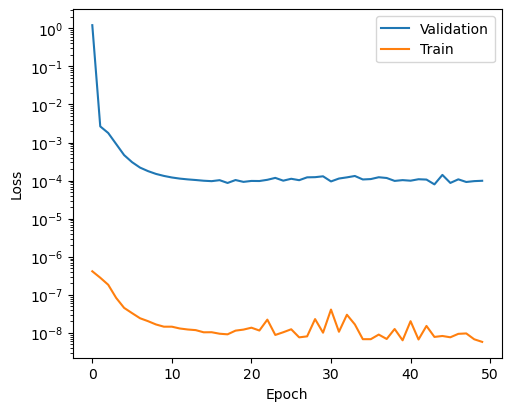

In [10]:
ani = ANITrainer(model=model, batch_size=32, learning_rate=1e-2, epoch=50, l2=0)
ani.train(train_data, val_data)

## Output Visualization

tensor(5.9128e-09, device='cuda:0')

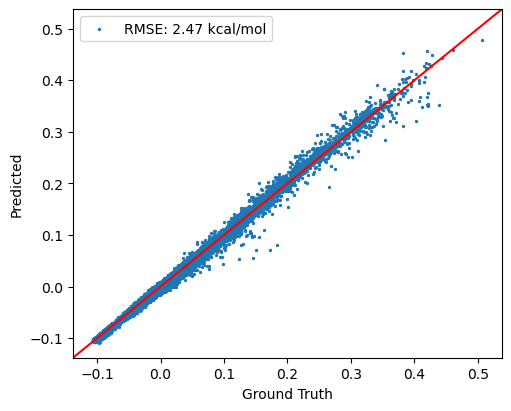

In [11]:
ani.evaluate(test_data, draw_plot=True)

Testing yielded in an RMSE of 2.47 kcal/mol, performing worse than the best model investigated by Smith et al.: ANI-1, which had an RMSE of 1.8 kcal/mol (1). However, it did outperform the other three models they investigated: DFTB, AM1, and PM6, with RMSE values of 10.2, 16.2, and 22.0 kcal/mol, respectively (1).

1. Smith, J. S.; Isayev, O.; Roitberg, A. E. ANI-1: an extensible neural network potential with DFT accuracy at force field computational cost. Chemical Science 2017, 8(4), 3192–3203. DOI: 10.1039/C6SC05720A